#Download dataset

In [1]:
# Step 1: Install kaggle
!pip install kaggle -q

# Step 2: Set up API key
import os
os.makedirs('/root/.kaggle', exist_ok=True)

api_key_content = '{"username":"vaqudah","key":"KGAT_03544500e30f8e078c185bec3c12ec63"}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(api_key_content)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Step 3: Download dataset
!kaggle datasets download -d vaqudah/deepfake -p /content/data

# Step 4: Unzip
!unzip -q /content/data/deepfake.zip -d /content/data

# Step 5: Check structure
!find /content/data -type d

Dataset URL: https://www.kaggle.com/datasets/vaqudah/deepfake
License(s): unknown
100% 4.56G/4.56G [04:37<00:00, 17.6MB/s]

/content/data
/content/data/split_dataset
/content/data/split_dataset/DMs
/content/data/split_dataset/DMs/train
/content/data/split_dataset/DMs/test
/content/data/split_dataset/Real
/content/data/split_dataset/Real/train
/content/data/split_dataset/Real/test
/content/data/split_dataset/GANs
/content/data/split_dataset/GANs/train
/content/data/split_dataset/GANs/test


In [2]:
import os

base = '/content/data/split_dataset'
classes = ['Real', 'GANs', 'DMs']

for cls in classes:
    for split in ['train', 'test']:
        path = os.path.join(base, cls, split)
        count = len(os.listdir(path))
        print(f"{cls}/{split}: {count} images")

Real/train: 14835 images
Real/test: 2618 images
GANs/train: 14835 images
GANs/test: 2618 images
DMs/train: 14835 images
DMs/test: 2618 images


In [5]:
import os
import shutil
import random

random.seed(42)

base = '/content/data/split_dataset'
output2 = '/content/data/baseline_binary'

splits = {
    'train': {'Real': 4000, 'Fake': 4000},  # 2000 DMs + 2000 GANs
    'test':  {'Real': 1000, 'Fake': 1000}   # 500 DMs + 500 GANs
}

for split, classes in splits.items():
    # Real
    src = os.path.join(base, 'Real', split)
    dst = os.path.join(output2, split, 'Real')
    os.makedirs(dst, exist_ok=True)
    selected = random.sample(os.listdir(src), classes['Real'])
    for img in selected:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))

    # Fake = DMs + GANs
    dst = os.path.join(output2, split, 'Fake')
    os.makedirs(dst, exist_ok=True)
    n_each = classes['Fake'] // 2  # 2000 أو 500 من كل واحد

    for cls in ['DMs', 'GANs']:
        src = os.path.join(base, cls, split)
        selected = random.sample(os.listdir(src), n_each)
        for img in selected:
            shutil.copy(os.path.join(src, img), os.path.join(dst, f"{cls}_{img}"))

# تحقق
for split in ['train', 'test']:
    for cls in ['Real', 'Fake']:
        path = os.path.join(output2, split, cls)
        print(f"{split}/{cls}: {len(os.listdir(path))} images")

train/Real: 4000 images
train/Fake: 4000 images
test/Real: 1000 images
test/Fake: 1000 images


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('/content/data/baseline_binary/train', transform=transform)
test_dataset  = datasets.ImageFolder('/content/data/baseline_binary/test',  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Classes: {train_dataset.classes}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Classes: ['Fake', 'Real']
Train batches: 250
Test batches:  63


Epoch [1/10] | Train Loss: 0.0870 | Test Loss: 0.0355 | Test Acc: 98.90% | Time: 94.5s
Epoch [2/10] | Train Loss: 0.0241 | Test Loss: 0.0196 | Test Acc: 99.35% | Time: 93.6s
Epoch [3/10] | Train Loss: 0.0129 | Test Loss: 0.0345 | Test Acc: 98.85% | Time: 93.2s
Epoch [4/10] | Train Loss: 0.0113 | Test Loss: 0.0469 | Test Acc: 97.95% | Time: 94.5s
Epoch [5/10] | Train Loss: 0.0090 | Test Loss: 0.0299 | Test Acc: 98.80% | Time: 94.0s
Epoch [6/10] | Train Loss: 0.0030 | Test Loss: 0.0245 | Test Acc: 99.15% | Time: 93.3s
Epoch [7/10] | Train Loss: 0.0193 | Test Loss: 0.0103 | Test Acc: 99.65% | Time: 93.7s
Epoch [8/10] | Train Loss: 0.0075 | Test Loss: 0.0140 | Test Acc: 99.60% | Time: 94.4s
Epoch [9/10] | Train Loss: 0.0009 | Test Loss: 0.0079 | Test Acc: 99.75% | Time: 94.0s
Epoch [10/10] | Train Loss: 0.0085 | Test Loss: 0.0117 | Test Acc: 99.60% | Time: 92.9s


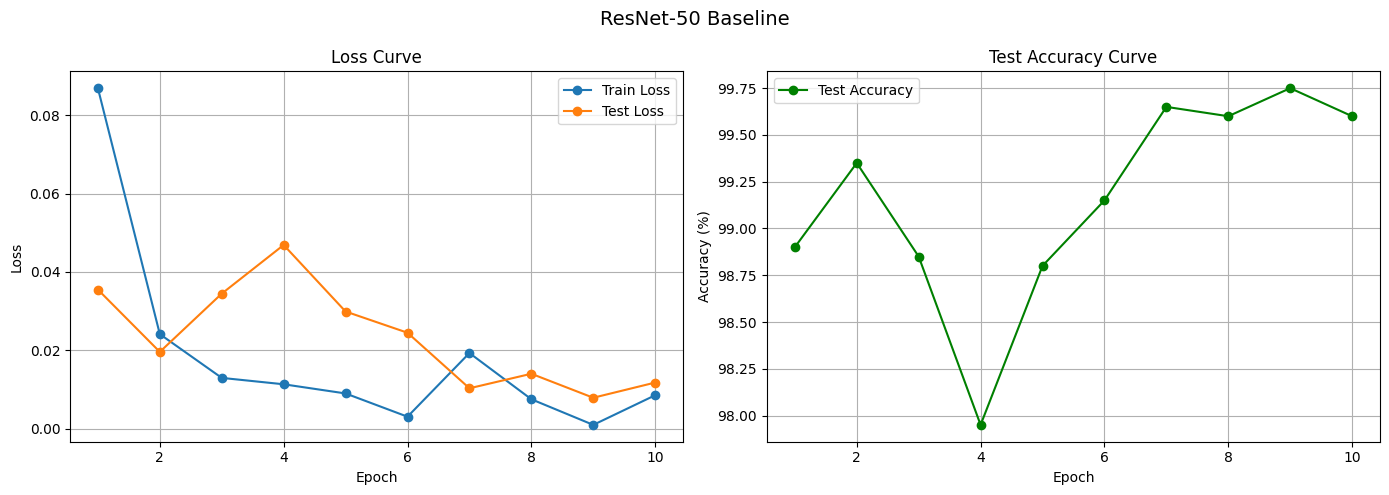

In [8]:
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import time

# ========== Model ==========
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to('cuda')

# ========== Loss & Optimizer ==========
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# ========== Training ==========
epochs = 10
train_losses = []
test_losses  = []
test_accs    = []

for epoch in range(epochs):
    start = time.time()

    # --- Train ---
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to('cuda'), labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # --- Test ---
    model.eval()
    running_loss = 0
    correct = 0
    total   = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to('cuda'), labels.to('cuda')
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    test_loss = running_loss / len(test_loader)
    test_acc  = correct / total * 100
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    elapsed = time.time() - start
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | Time: {elapsed:.1f}s")

# ========== Plot ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
ax1.plot(range(1, epochs+1), test_losses,  label='Test Loss',  marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, epochs+1), test_accs, label='Test Accuracy', marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy Curve')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet-50 Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('baseline_curves.png', dpi=150)
plt.show()

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      1000
        Real       0.99      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



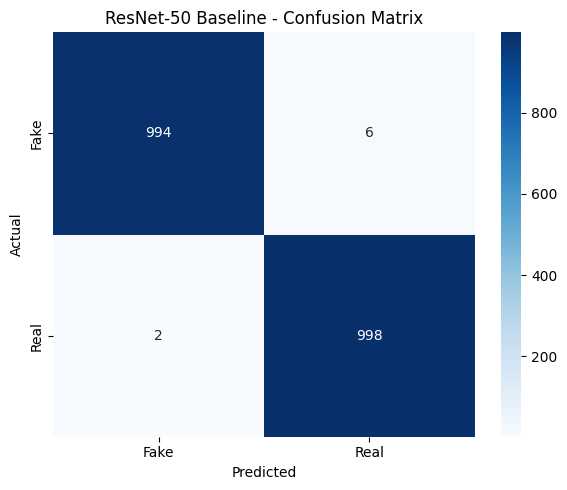

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ========== Predictions ==========
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to('cuda'), labels.to('cuda')
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ========== Classification Report ==========
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# ========== Confusion Matrix ==========
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet-50 Baseline - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [17]:
from PIL import Image
import torch
from torchvision import transforms

# ========== Transform ==========
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ========== Predict Function ==========
def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = infer_transform(img).unsqueeze(0).to('cuda')

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    classes = ['Fake', 'Real']
    label = classes[predicted.item()]
    conf  = confidence.item() * 100

    print(f"Prediction : {label}")
    print(f"Confidence : {conf:.2f}%")

    return label, conf

# ========== Test ==========
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    predict(filename)

Saving 11_face1.png to 11_face1.png
Prediction : Fake
Confidence : 100.00%


In [18]:
# ========== Save Model ==========
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'test_accs': test_accs,
    'classes': train_dataset.classes,
    'epochs': epochs,
    'final_test_acc': test_accs[-1],
    'best_test_acc': max(test_accs),
}, 'resnet50_baseline.pth')

print("Model saved!")
print(f"Final Accuracy : {test_accs[-1]:.2f}%")
print(f"Best  Accuracy : {max(test_accs):.2f}%")
print(f"Classes        : {train_dataset.classes}")

Model saved!
Final Accuracy : 99.60%
Best  Accuracy : 99.75%
Classes        : ['Fake', 'Real']


In [19]:
from google.colab import files
files.download('resnet50_baseline.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>